# Feature Engineering - Final Preparation

## 1.0 Imports and Config

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 2.0 Data Loading and Initial Cleaning

In [2]:
df = pd.read_csv('../data/student_data_cleaned.csv')

# Dropping identifiers and columns that cause Target Leakage
cols_to_drop = [
    'student_id', 'semester_id', 'enrollment_date', 'birth_year', 
    'zip_code', 'major_code', 'major_name_en', 'status_at_record'
]

df_filtered = df.drop(columns=cols_to_drop)

## 3.0 Advanced Feature Engineering

In [3]:
# 1. Performance Trends & Success Rates
df_filtered['term_success_rate'] = df_filtered['credits_done_term'] / df_filtered['credits_taken_term'].replace(0, 1)
df_filtered['cum_success_rate'] = df_filtered['credits_done_cum'] / df_filtered['credits_taken_cum'].replace(0, 1)
df_filtered['gpa_trend'] = df_filtered['gpa_term'] - df_filtered['gpa_cum']

# 2. Debt and Efficiency
df_filtered['missed_credits_total'] = df_filtered['credits_taken_cum'] - df_filtered['credits_done_cum']
df_filtered['credit_loss_ratio'] = (df_filtered['credits_taken_term'] - df_filtered['credits_done_term']) / df_filtered['credits_taken_term'].replace(0, 1)

# 3. Age and Phase Flags
df_filtered['is_mature_student'] = (df_filtered['age_at_enrollment'] > 25).astype(int)
df_filtered['is_first_year'] = (df_filtered['term_number'] <= 2).astype(int)
df_filtered['high_load_flag'] = (df_filtered['credits_taken_term'] > 35).astype(int)

## 3.1 Funding Simplification

In [4]:
self_funded_keywords = ['Tuition-fee', 'Self-funded', 'Paying']

df_filtered['is_self_funded'] = df_filtered.apply(
    lambda x: 1 if any(kw in str(x['funding_type']) or kw in str(x['funding_category']) for kw in self_funded_keywords) else 0, 
    axis=1
)

df_filtered = df_filtered.drop(columns=['funding_type', 'funding_category'])

## 4.0 Categorical Encoding and Leakage Removal

Based on the correlation matrix, we drop 'semester_active_status' to prevent the model from cheating with current status markers.

In [5]:
# Removed 'semester_active_status' from encoding to avoid target leakage (Correlation > 0.5)
categorical_cols = [
    'gender', 'county', 'university', 'major_field_broad', 
    'degree_level', 'study_mode'
]

df_final = pd.get_dummies(df_filtered, columns=categorical_cols, drop_first=True, dtype=int)

# Ensure all engineered flags and target are integers
target_and_flags = ['is_churned', 'is_mature_student', 'is_first_year', 'high_load_flag', 'is_self_funded']
df_final[target_and_flags] = df_final[target_and_flags].astype(int)

# Final drop of columns that might still contain the text version of status if not already handled
if 'semester_active_status' in df_final.columns:
    df_final = df_final.drop(columns=['semester_active_status'])

## 5.0 Correlation Analysis (Post-Filtering)

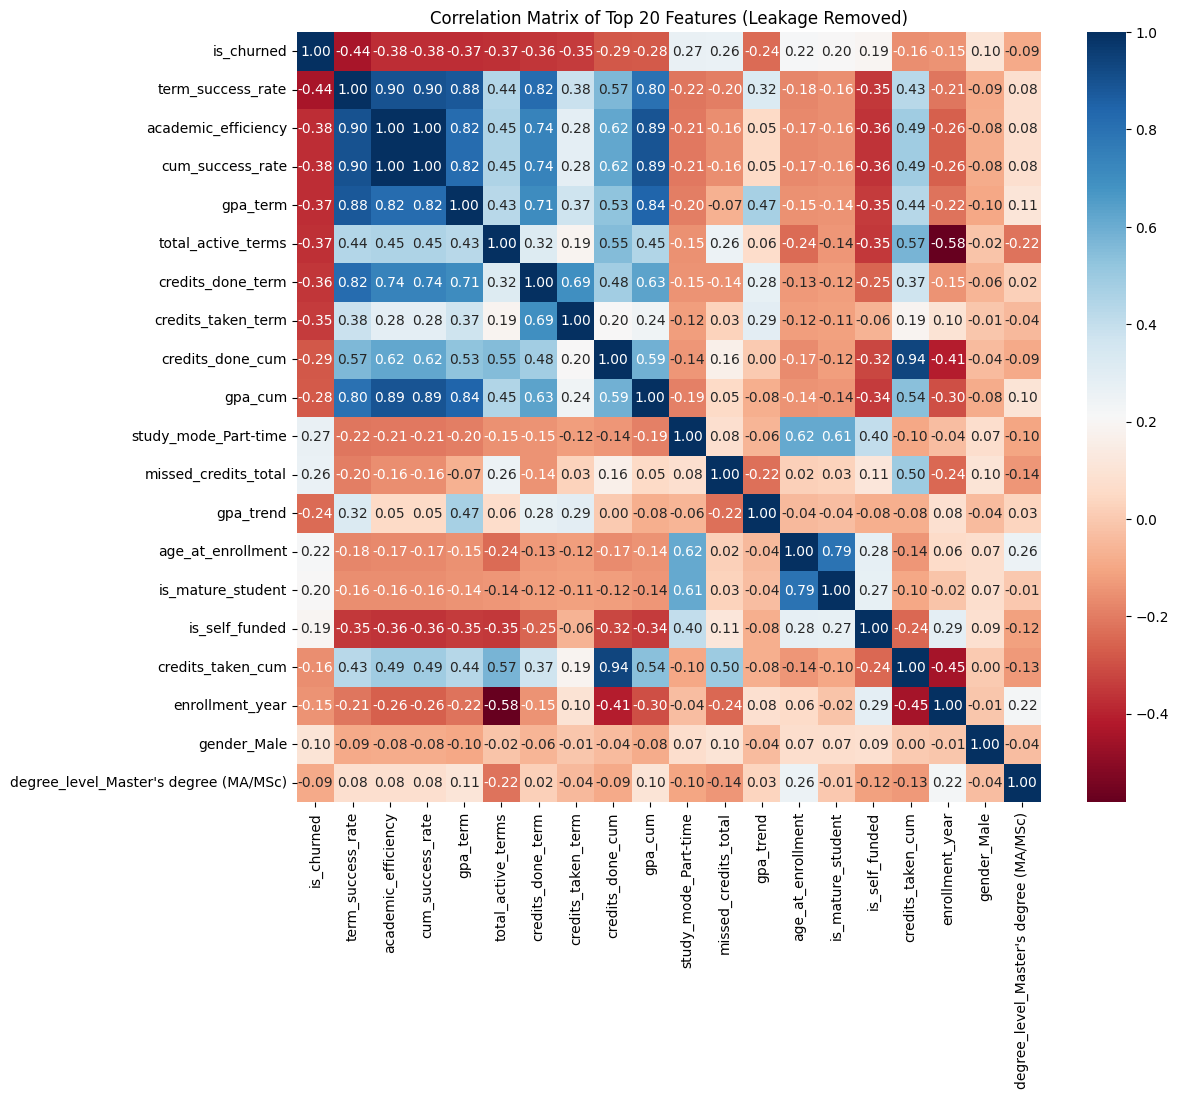

Top correlations with Churn after cleaning:
is_churned              1.000000
study_mode_Part-time    0.269714
missed_credits_total    0.264270
age_at_enrollment       0.219725
is_mature_student       0.204779
is_self_funded          0.191341
gender_Male             0.099264
credit_loss_ratio       0.068554
is_first_year           0.056583
county_Budapest         0.048661
Name: is_churned, dtype: float64


In [6]:
correlations = df_final.corr()['is_churned'].sort_values(ascending=False)
top_features = correlations.abs().sort_values(ascending=False).head(20).index
plt.figure(figsize=(12, 10))
sns.heatmap(df_final[top_features].corr(), annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation Matrix of Top 20 Features (Leakage Removed)')
plt.show()

print("Top correlations with Churn after cleaning:")
print(correlations.head(10))

## 6.0 Final Export

In [7]:
df_final.to_csv('../data/student_data_final.csv', index=False, encoding='utf-8')
print(f"Final Feature Set Shape: {df_final.shape}")
print("Process complete. Data saved for modeling.")

Final Feature Set Shape: (63233, 49)
Process complete. Data saved for modeling.
